In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

In [ ]:
df=pd.read_csv("/content/ds3.csv.zip",compression="zip")

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df["text"]=df["title"]+","+df["title"]
df['clean_text'] = df['text'].apply(preprocess)

In [ ]:
df = df.drop(columns=["type"]).drop_duplicates()

In [ ]:
X = df["clean_text"]
y = df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
max_words = 50000
max_len = 500
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text'])
X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=max_len)
y = df['label']

In [ ]:
model1 = Sequential([
    Embedding(50000, 128, input_length=max_len),
    LSTM(128, dropout=0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
X_train_processed = tokenizer.texts_to_sequences(X_train)
X_train_processed = pad_sequences(X_train_processed, maxlen=max_len)
history1 = model1.fit(X_train_processed, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1039s 1s/step - accuracy: 0.9303 - loss: 0.1788 - val_accuracy: 0.9577 - val_loss: 0.1147
Epoch 2/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1026s 1s/step - accuracy: 0.9801 - loss: 0.0572 - val_accuracy: 0.9538 - val_loss: 0.1328
Epoch 3/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1012s 1s/step - accuracy: 0.9925 - loss: 0.0217 - val_accuracy: 0.9555 - val_loss: 0.1633
Epoch 4/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1005s 1s/step - accuracy: 0.9965 - loss: 0.0107 - val_accuracy: 0.9541 - val_loss: 0.1725
Epoch 5/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1018s 1s/step - accuracy: 0.9982 - loss: 0.0057 - val_accuracy: 0.9384 - val_loss: 0.3634


In [ ]:
X_test_processed = tokenizer.texts_to_sequences(X_test)
X_test_processed = pad_sequences(X_test_processed, maxlen=max_len)

y_pred = model1.predict(X_test_processed)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

280/280 ━━━━━━━━━━━━━━━━━━━━ 76s 272ms/step
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4695
           1       0.98      0.91      0.94      4238

    accuracy                           0.95      8933
   macro avg       0.95      0.95      0.95      8933
weighted avg       0.95      0.95      0.95      8933



In [ ]:
model = Sequential([
    Embedding(max_words, 128, input_length=max_len),
    Bidirectional(LSTM(128, dropout=0.3)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
X_train_processed = tokenizer.texts_to_sequences(X_train)
X_train_processed = pad_sequences(X_train_processed, maxlen=max_len)
history_bidirectional = model.fit(X_train_processed, y_train, epochs=5, batch_size=32, validation_split=0.1)

Epoch 1/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1925s 2s/step - accuracy: 0.9312 - loss: 0.1716 - val_accuracy: 0.9583 - val_loss: 0.1096
Epoch 2/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1984s 2s/step - accuracy: 0.9802 - loss: 0.0566 - val_accuracy: 0.9589 - val_loss: 0.1156
Epoch 3/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1896s 2s/step - accuracy: 0.9932 - loss: 0.0202 - val_accuracy: 0.9485 - val_loss: 0.1577
Epoch 4/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1893s 2s/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9446 - val_loss: 0.2071
Epoch 5/5
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 1861s 2s/step - accuracy: 0.9986 - loss: 0.0047 - val_accuracy: 0.9485 - val_loss: 0.2941


In [ ]:
X_test_processed = tokenizer.texts_to_sequences(X_test)
X_test_processed = pad_sequences(X_test_processed, maxlen=max_len)

y_pred = model.predict(X_test_processed)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

280/280 ━━━━━━━━━━━━━━━━━━━━ 130s 463ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      4695
           1       0.96      0.94      0.95      4238

    accuracy                           0.95      8933
   macro avg       0.95      0.95      0.95      8933
weighted avg       0.95      0.95      0.95      8933



280/280 ━━━━━━━━━━━━━━━━━━━━ 136s 487ms/step


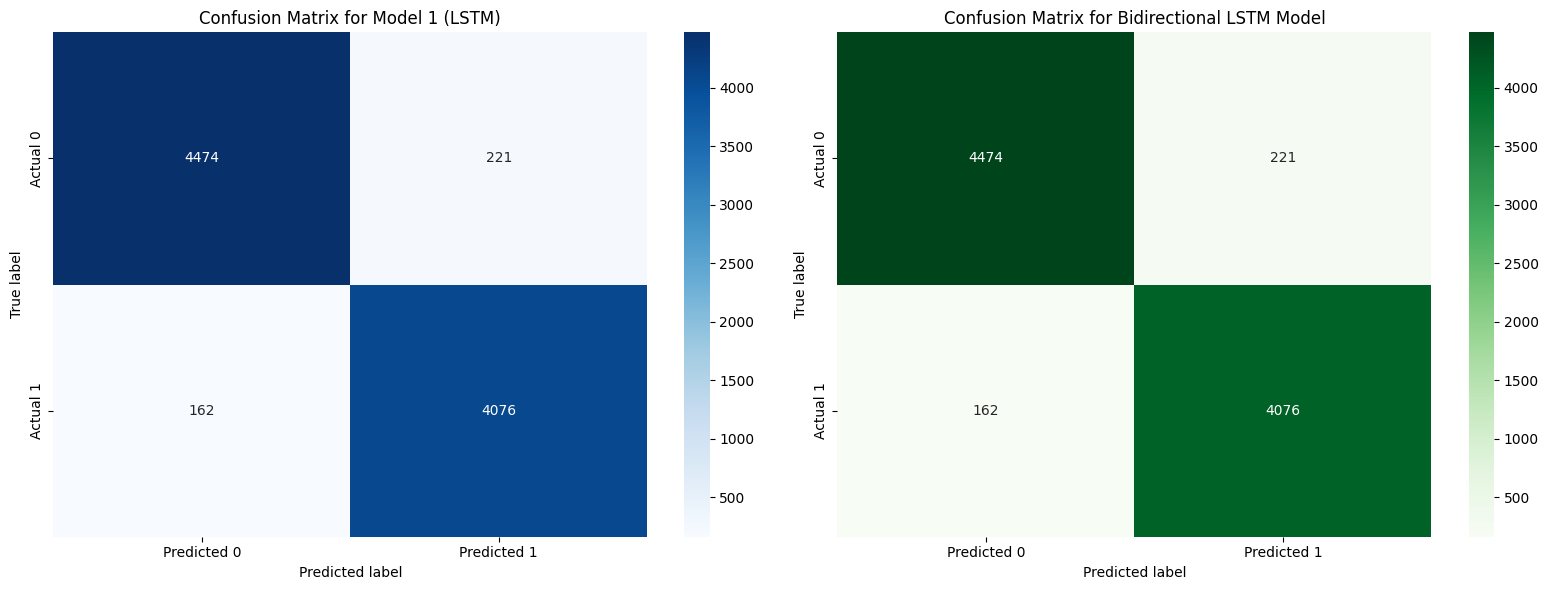

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm1 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm1, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[0])
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')
axes[0].set_title('Confusion Matrix for Model 1 (LSTM)')

X_test_processed_bidirectional = tokenizer.texts_to_sequences(X_test)
X_test_processed_bidirectional = pad_sequences(X_test_processed_bidirectional, maxlen=max_len)
y_pred_bidirectional = model.predict(X_test_processed_bidirectional)
y_pred_bidirectional = (y_pred_bidirectional > 0.5).astype(int)

cm_bidirectional = confusion_matrix(y_test, y_pred_bidirectional)
sns.heatmap(cm_bidirectional, annot=True, fmt='g', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'], ax=axes[1])
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Confusion Matrix for Bidirectional LSTM Model')

plt.tight_layout()
plt.show()

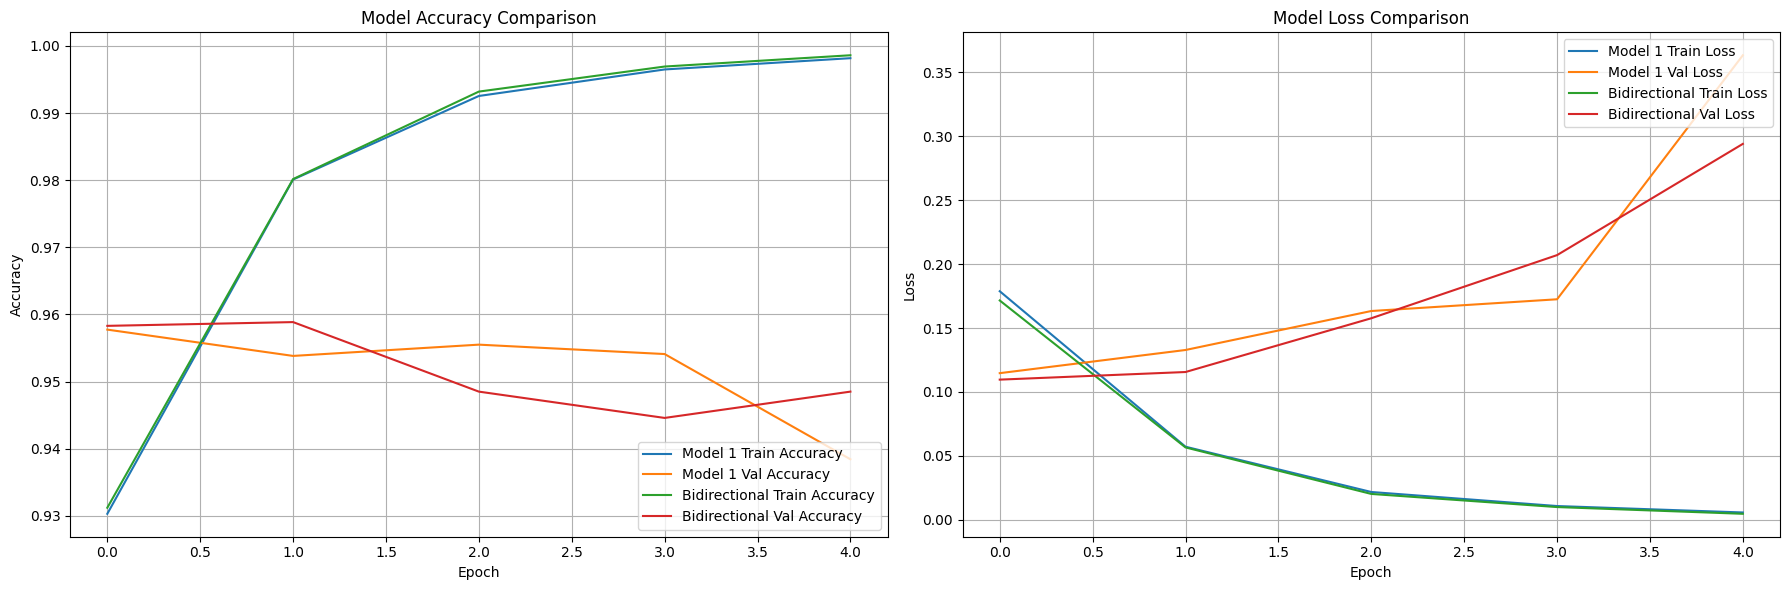

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(history1.history['accuracy'], label='Model 1 Train Accuracy')
axes[0].plot(history1.history['val_accuracy'], label='Model 1 Val Accuracy')

axes[0].plot(history_bidirectional.history['accuracy'], label='Bidirectional Train Accuracy')
axes[0].plot(history_bidirectional.history['val_accuracy'], label='Bidirectional Val Accuracy')

axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='lower right')
axes[0].grid(True)

axes[1].plot(history1.history['loss'], label='Model 1 Train Loss')
axes[1].plot(history1.history['val_loss'], label='Model 1 Val Loss')

axes[1].plot(history_bidirectional.history['loss'], label='Bidirectional Train Loss')
axes[1].plot(history_bidirectional.history['val_loss'], label='Bidirectional Val Loss')

axes[1].set_title('Model Loss Comparison')
axes[1].set_ylabel('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.show()